# Análisis Exploratorio de Datos (EDA) - MUSAN Dataset
## Proyecto C: Audio Source Separation via NMF
**Optimización Numérica | Iberoamericana León 2026**
---
Ejecutar localmente con Jupyter.  
Los outputs (PNG + CSV) se suben a GitHub en la carpeta `outputs/`.

# 1. Configuración Inicial y Parámetros Globales

Esta primera celda establece el entorno de trabajo fundamental para nuestro análisis exploratorio del dataset MUSAN, el cual es un paso obligatorio antes de implementar el algoritmo BCGD.

**¿Qué hace este bloque de código?**

*   **Importación de Librerías:** 
    *   Cargamos herramientas estándar para manipulación de datos (`numpy`, `pandas`) y visualización avanzada (`matplotlib`, `seaborn`).
    *   Para el procesamiento especializado de señales de audio, utilizamos `librosa` y `soundfile`, que nos permitirán extraer características acústicas clave y generar los espectrogramas.
*   **Gestión de Rutas:** Define explícitamente dónde residen los datos crudos del corpus MUSAN (`DATA_ROOT`) y dónde se guardarán todas las gráficas y reportes generados (`OUTPUT_DIR`).
*   **Parámetros de Procesamiento Acústico (NMF Target):**
    *   `N_PER_CAT = 30`: Tomamos una muestra representativa inicial de 30 audios por categoría para acelerar el EDA sin procesar las ~109 horas del dataset completo de golpe.
    *   `SR_TARGET = 22050`: Estandarizamos la frecuencia de muestreo de todos los audios a 22.05 kHz. Esto es un buen equilibrio entre preservar las frecuencias útiles para separación (hasta ~11 kHz) y mantener una carga computacional manejable.
    *   `N_FFT = 1024` y `HOP_LENGTH = 512`: Estos son los hiperparámetros cruciales para la Transformada de Fourier a Corto Plazo (STFT). Generarán una matriz $X \in \mathbb{R}_{\ge0}^{F\times T}$ con $F = 513$ bins de frecuencia. Esta matriz $X$ será la entrada directa para nuestro algoritmo NMF.
*   **Estética:** Se define un diccionario `PALETTE` para asegurar que los colores de las categorías (*Music*, *Noise*, *Speech*) sean consistentes en todas las gráficas generadas.

In [1]:
# Importación de librerías y configuración inicial

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from scipy import stats
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Rutas
DATA_ROOT   = r'C:\Users\frank\OneDrive\Documentos\Ibero Semestres\6tosemestre\Python\data\musan'
OUTPUT_DIR  = r'C:\Users\frank\OneDrive\Documentos\Ibero Semestres\6tosemestre\Python\OptimizacionM\nmf-audio-separation\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parámetros del proyecto
N_PER_CAT   = 30 
N_FFT       = 1024
HOP_LENGTH  = 512
SR_TARGET   = 22050
CATEGORIES  = ['music', 'noise', 'speech']

# Paleta de colores
PALETTE = {
    'music': '#4C72B0', 'noise': '#DD8452', 'speech': '#55A868',
    'bg': '#F8F9FA', 'grid': '#DEE2E6', 'text': '#212529',
}
CAT_LABELS = {'music': 'Music', 'noise': 'Noise', 'speech': 'Speech'}

print(f'Datos  : {DATA_ROOT}')
print(f'Outputs: {OUTPUT_DIR}\n')
print('Setup completado. Librerías y rutas listas.')

c:\Users\frank\miniconda3\envs\py312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Datos  : C:\Users\frank\OneDrive\Documentos\Ibero Semestres\6tosemestre\Python\data\musan
Outputs: C:\Users\frank\OneDrive\Documentos\Ibero Semestres\6tosemestre\Python\OptimizacionM\nmf-audio-separation\outputs

Setup completado. Librerías y rutas listas.


# 2. EDA MUSAN

### 2.1 Funciones Modulares de Procesamiento y Extracción

Esta celda define las herramientas principales para leer, procesar y estandarizar los audios del dataset MUSAN. Al encapsular esta lógica en funciones, mantenemos el resto del notebook limpio y modular.

**Detalle de las funciones implementadas:**

*   **`scan_files` (Indexación y Muestreo Reproducible):**[cite: 3]
    *   **Propósito:** Navega por la ruta raíz buscando archivos de audio con extensiones `.wav`, `.flac` o `.mp3` dentro de las categorías especificadas[cite: 3].
    *   **Control de Semilla:** Si se especifica un límite de archivos (`n_per_cat`), realiza un muestreo aleatorio utilizando un generador con semilla fija (`seed=42`)[cite: 3]. Esto es vital para la reproducibilidad: garantiza que cualquier miembro del equipo que ejecute el notebook obtenga exactamente la misma muestra de audios.
    *   **Salida:** Retorna un DataFrame de Pandas estructurado con los metadatos de los archivos (ruta, tamaño, nombre y categoría)[cite: 3].

*   **`analyze_file` (Extracción Acústica y Generación de Matriz STFT):**[cite: 3]
    *   **Carga y Estandarización:** Carga el archivo de audio usando `librosa`, lo convierte a formato monoaural y fuerza la frecuencia de muestreo al valor unificado `SR_TARGET` (22050 Hz)[cite: 3]. Para proteger la memoria RAM, recorta la lectura a un máximo de 30 segundos (`max_dur=30.0`)[cite: 3].
    *   **Conexión directa con NMF:** Calcula la Transformada de Fourier a Corto Plazo (STFT) y extrae su magnitud absoluta (`np.abs`)[cite: 3]. Las dimensiones y los valores de esta matriz `S` se guardan en el reporte, ya que esta es exactamente la **matriz $X$** no negativa que nuestro algoritmo BCGD va a factorizar.
    *   **Extracción de Features:** Calcula descriptores acústicos fundamentales (Energía RMS, Zero Crossing Rate, Centroide Espectral, Ancho de Banda y Rolloff) promediados a lo largo del tiempo para perfilar las diferencias entre música, voz y ruido[cite: 3].
    *   **Tolerancia a fallos:** Toda la lógica está envuelta en un bloque `try-except`[cite: 3]. Si encuentra un archivo corrupto, simplemente lo marca con una bandera `ok: False` y captura el error sin detener la ejecución de todo el ciclo[cite: 3].

*   **`ax_style` (Estandarización Visual):**[cite: 3]
    *   **Propósito:** Función auxiliar para inyectar estilo a los objetos `Axes` de Matplotlib. Aplica nuestra paleta de colores personalizada (`PALETTE`), estandariza las fuentes y dibuja las cuadrículas de fondo[cite: 3]. Esto asegura que todas las gráficas del EDA tengan un acabado visual coherente y profesional.

In [2]:
# Celda 1
# FUNCIONES DE PROCESAMIENTO

def scan_files(data_root, categories, n_per_cat=None, exts=('.wav','.flac','.mp3')):
    """Escanea carpetas y devuelve DataFrame con metadatos de archivos."""
    rows = []
    for cat in categories:
        path = Path(data_root) / cat
        if not path.exists(): continue
        files = [f for f in path.rglob('*') if f.suffix.lower() in exts]
        if n_per_cat and len(files) > n_per_cat:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(files), n_per_cat, replace=False)
            files = [files[i] for i in sorted(idx)]
        for f in files:
            rows.append({
                'category': cat, 'path': str(f), 'filename': f.name,
                'size_bytes': f.stat().st_size, 'subdir': str(f.parent.relative_to(path)),
            })
    return pd.DataFrame(rows)

def analyze_file(path, sr_target=SR_TARGET, max_dur=30.0):
    """Extrae características acústicas y de espectrograma de un archivo."""
    try:
        info = sf.info(path)
        y, sr = librosa.load(path, sr=sr_target, mono=True, duration=max_dur)
        S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))
        return {
            'ok': True, 'sr_original': info.samplerate, 'channels': info.channels,
            'duration_s': info.duration, 'format': info.format,
            'rms_energy': float(np.sqrt(np.mean(y**2))),
            'zero_cross_rate': float(np.mean(librosa.feature.zero_crossing_rate(y))),
            'spectral_centroid_hz': float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
            'spectral_bandwidth': float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
            'spectral_rolloff_hz': float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))),
            'stft_F': S.shape[0], 'stft_T': S.shape[1],
            'stft_mean': float(S.mean()), 'stft_max': float(S.max()),
        }
    except Exception as e:
        return {'ok': False, 'error': str(e)}

def ax_style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor(PALETTE['bg'])
    ax.set_title(title, fontsize=9.5, fontweight='bold', pad=6, color=PALETTE['text'])
    ax.set_xlabel(xlabel, fontsize=8, color='#495057')
    ax.set_ylabel(ylabel, fontsize=8, color='#495057')
    ax.tick_params(labelsize=7.5, colors='#495057')
    ax.grid(True, color=PALETTE['grid'], linewidth=0.5, alpha=0.8, zorder=0)
    for sp in ax.spines.values(): sp.set_edgecolor(PALETTE['grid'])

## 2.2 Ejecución del Pipeline de Extracción y Resumen de Metadatos

En esta celda ponemos a trabajar las funciones previamente definidas. Aquí iteramos sobre nuestra muestra de archivos, extraemos sus características acústicas y consolidamos la información en tablas estructuradas (DataFrames) para su posterior análisis visual y exportación.

**Flujo de ejecución:**

*   **Procesamiento en Lote (Batch Processing):** 
    *   Utilizamos `scan_files` para obtener la lista de los archivos a procesar[cite: 3].
    *   Iteramos sobre cada archivo usando `tqdm` para mostrar una barra de progreso[cite: 3]. Esto es una gran ayuda visual, ya que el procesamiento de señales de audio con `librosa` puede ser intensivo en tiempo y CPU.
    *   A cada archivo se le aplica la función `analyze_file`, fusionando los metadatos del sistema (como la ruta) con las métricas acústicas extraídas[cite: 3].
*   **Limpieza y Manejo de Errores:** 
    *   Filtramos los resultados separando los archivos procesados exitosamente (`df_ok`) de aquellos que arrojaron algún error de lectura (`errors`)[cite: 3]. Esto garantiza que nuestros datos de análisis estén limpios.
*   **Agrupación y Estadísticas (Summary):** 
    *   Utilizamos la función `groupby` de Pandas para generar un resumen estadístico por categoría de audio (Music, Noise, Speech)[cite: 3]. 
    *   Calculamos métricas consolidadas como la duración total en minutos, la media de energía RMS y el Zero Crossing Rate (ZCR) promedio[cite: 3]. Esto nos da una visión "a vista de pájaro" de las diferencias entre las clases.
*   **Persistencia (Guardado en disco):** 
    *   Exportamos tanto los metadatos completos (`metadata_MUSAN.csv`) como el resumen consolidado (`summary_MUSAN.csv`) a la carpeta de salida (`OUTPUT_DIR`)[cite: 3]. Al guardar estos CSVs, evitamos tener que recalcular la extracción de características en futuras sesiones.
*   **Preparativos para Visualización:** 
    *   Definimos listas de variables auxiliares (`cats`, `colors`, `labels`) extrayendo únicamente las categorías presentes en nuestros archivos válidos y mapeándolas a nuestra paleta de colores estándar[cite: 3]. Esto prepara el terreno para las gráficas siguientes.

In [3]:
# Celda 2
# EXTRACCIÓN DE DATOS Y METADATOS

print(f'Escaneando (muestra: {N_PER_CAT} por categoría)...')
df_files = scan_files(DATA_ROOT, CATEGORIES, n_per_cat=N_PER_CAT)

records = []
for _, row in tqdm(df_files.iterrows(), total=len(df_files), desc='Analizando'):
    meta = analyze_file(row['path'])
    meta.update(row.to_dict())
    records.append(meta)

df = pd.DataFrame(records)
df_ok = df[df['ok'] == True].copy()
errors = df[df['ok'] != True]

print(f'\n{len(df_ok)}/{len(df_files)} archivos OK')
if len(errors) > 0:
    print(f'{len(errors)} errores:')
    print(errors[['filename','error']].to_string(index=False))

# Guardar CSVs
df_ok.to_csv(f'{OUTPUT_DIR}/metadata_MUSAN.csv', index=False)
summary = df_ok.groupby('category').agg(
    n_archivos          = ('filename', 'count'),
    dur_total_min       = ('duration_s', lambda x: round(x.sum()/60, 2)),
    dur_media_s         = ('duration_s', lambda x: round(x.mean(), 2)),
    rms_media           = ('rms_energy', lambda x: round(x.mean(), 5)),
    zcr_media           = ('zero_cross_rate', lambda x: round(x.mean(), 5)),
    centroide_hz        = ('spectral_centroid_hz', lambda x: round(x.mean(), 1)),
    stft_F              = ('stft_F', 'first'),
    tamano_MB           = ('size_bytes', lambda x: round(x.sum()/1e6, 1)),
)
summary.to_csv(f'{OUTPUT_DIR}/summary_MUSAN.csv')

# Variables auxiliares para los gráficos
cats = [c for c in CATEGORIES if c in df_ok['category'].unique()]
colors = [PALETTE[c] for c in cats]
labels = [CAT_LABELS[c] for c in cats]
Categorias_limpias = ['Music', 'Noise', 'Speech']

display(summary)

Escaneando (muestra: 30 por categoría)...


Analizando:   0%|          | 0/90 [00:00<?, ?it/s]


90/90 archivos OK


,n_archivos,dur_total_min,dur_media_s,rms_media,zcr_media,centroide_hz,stft_F,tamano_MB
category,,,,,,,,
music,30,100.61,201.23,0.15369,0.06806,1309.7,513,193.2
noise,30,8.10,16.20,0.11740,0.13536,2132.3,513,15.6
speech,30,272.66,545.32,0.09353,0.08699,1373.6,513,523.5


## 2.3 Visualización de Distribuciones (Duración y Energía RMS)

En esta celda generamos nuestras primeras exploraciones visuales avanzadas utilizando `matplotlib` y `seaborn`. El objetivo es comprender cómo se distribuyen físicamente nuestros audios en términos de longitud (tiempo) y volumen (energía), identificando posibles desbalances en el dataset MUSAN.

**Figura 1: Análisis de Duración Temporal**[cite: 3]
*   **Donut Chart (Izquierda):** Construimos un gráfico de pastel con un círculo central en blanco para mostrar el peso relativo de cada categoría en la duración total del dataset muestreado[cite: 3]. Esto es vital para saber si nuestro modelo estará sesgado hacia alguna clase (por ejemplo, si *Speech* domina masivamente en tiempo de exposición).
*   **Histograma + KDE (Derecha):** Mostramos la distribución de los audios en segundos[cite: 3]. Las barras del histograma muestran la frecuencia absoluta, mientras que la curva KDE (Kernel Density Estimation) suaviza los datos para mostrar la densidad de probabilidad de la duración de las pistas[cite: 3]. Las líneas punteadas verticales marcan la media de cada categoría[cite: 3].
*   **Exportación:** La gráfica se guarda automáticamente en `outputs/fig1_distribucion_duracion.png`[cite: 3].

**Figura 2: Análisis de Energía RMS (Root Mean Square)**[cite: 3]
*   **¿Qué es el RMS?:** La energía RMS es una medida de la "fuerza" o volumen percibido de la señal de audio.
*   **Layout con GridSpec:** Utilizamos `gridspec` para armar un lienzo de 3 paneles combinados que nos da distintas perspectivas estadísticas de la misma métrica de energía[cite: 3].
*   **Distribución Global (Arriba):** Un histograma superpuesto con KDE que compara la forma en que varía el volumen en la música, el ruido y el habla[cite: 3]. Nos ayuda a ver, por ejemplo, si la música suele ser consistentemente más fuerte que los silencios del habla.
*   **Boxplot Comparativo (Abajo Izquierda):** Un diagrama de caja y bigotes que resume los cuartiles estadísticos de la energía[cite: 3]. Es la mejor herramienta gráfica para identificar rápidamente *outliers* (valores atípicos, representados como puntos) en el volumen de nuestros audios[cite: 3].
*   **Violin Plot (Abajo Derecha):** Combina la información del boxplot con la densidad del KDE[cite: 3]. La "gordura" del violín nos muestra dónde se concentra la mayor parte de la energía RMS de cada categoría de forma muy intuitiva[cite: 3].
*   **Exportación:** La gráfica se guarda en `outputs/fig2_energia_rms.png`[cite: 3].

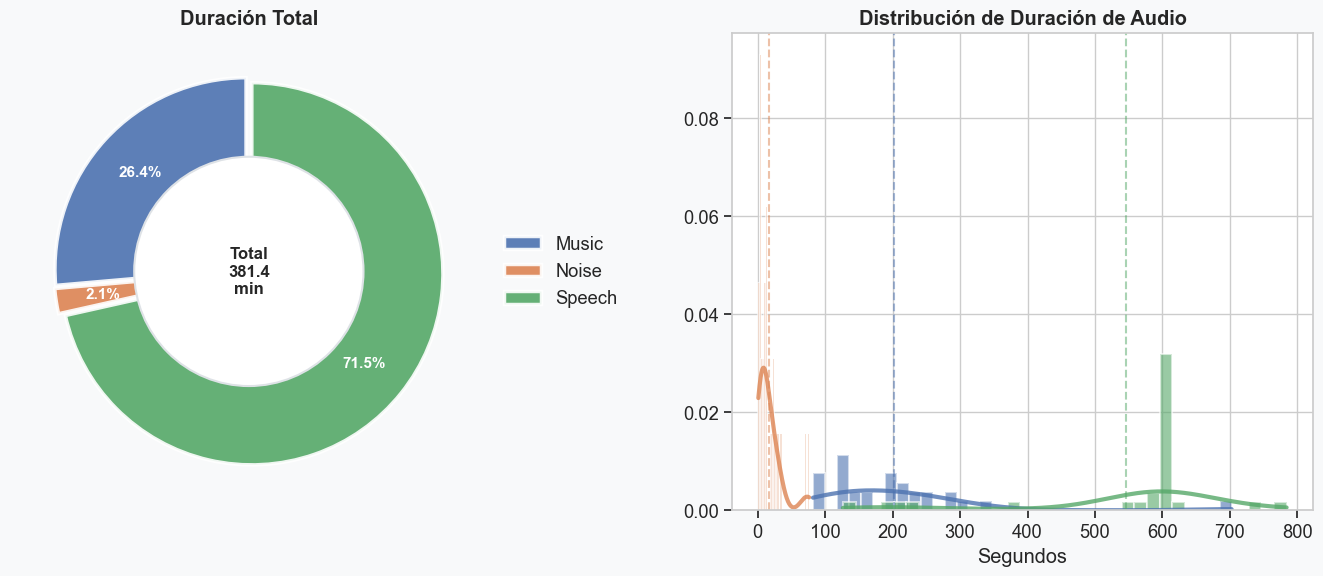

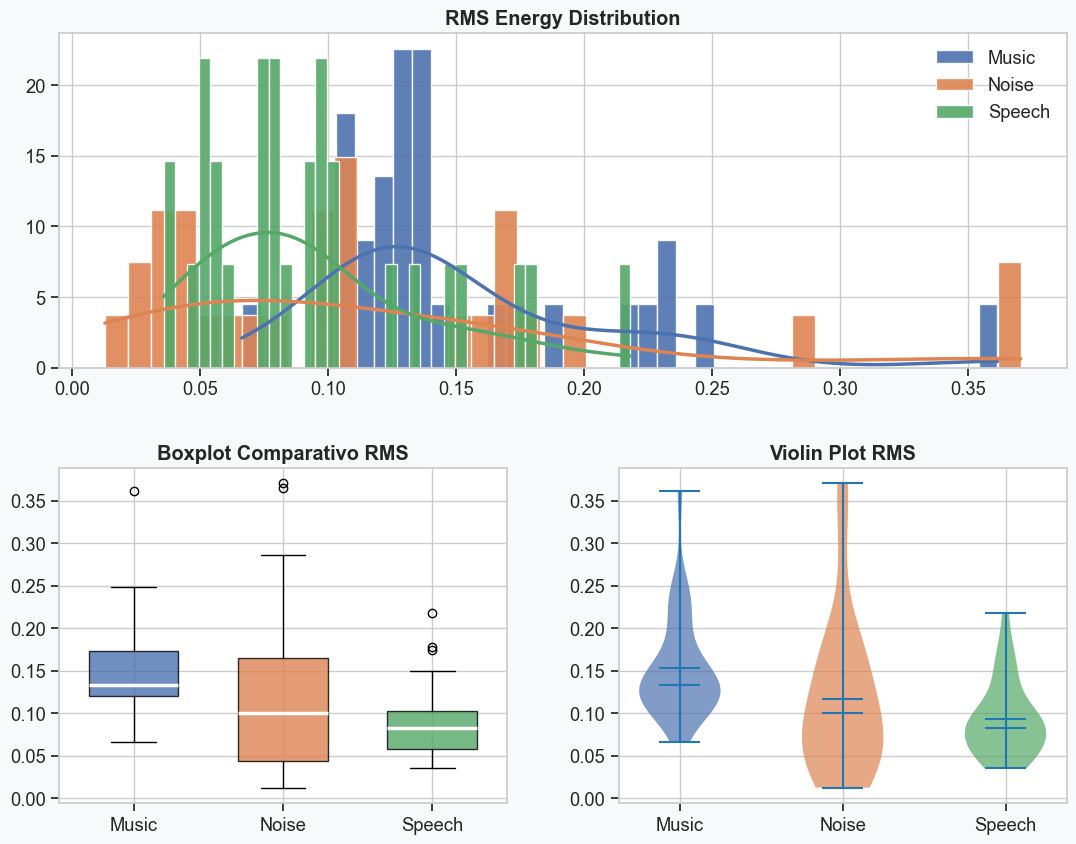

In [4]:
# Celda 3
# VISUALIZACIÓN DE DISTRIBUCIONES

dur_tot = [df_ok[df_ok['category']==c]['duration_s'].sum()/60 for c in cats]

# --- FIGURA 1: Distribución de Duración (Pie y KDE) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor=PALETTE['bg'])

# Pie Chart
wedges, texts, autotexts = ax1.pie(
    dur_tot, labels=None, colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5, alpha=0.9),
    textprops={'fontsize': 11, 'fontweight': 'bold'}, pctdistance=0.75,
    explode=[0.02] * len(cats)
)
for autotext in autotexts: autotext.set_color('white')
centre_circle = plt.Circle((0, 0), 0.60, fc='white', edgecolor=PALETTE['grid'], linewidth=1.5)
ax1.add_artist(centre_circle)
ax1.text(0, 0, f'Total\n{sum(dur_tot):.1f}\nmin', ha='center', va='center', fontsize=12, fontweight='bold')
ax1.legend(wedges, Categorias_limpias, loc='center left', bbox_to_anchor=(1, 0.5))
ax1.set_title('Duración Total', fontweight='bold')

# Histograma Duración
for cat, color, label in zip(cats, colors, labels):
    d = df_ok[df_ok['category']==cat]['duration_s'].dropna()
    ax2.hist(d, bins=35, color=color, alpha=0.6, label=label, edgecolor='white', lw=1.5, density=True)
    kde = stats.gaussian_kde(d)
    x_range = np.linspace(d.min(), d.max(), 200)
    ax2.plot(x_range, kde(x_range), color=color, lw=3, alpha=0.8)
    ax2.axvline(d.mean(), color=color, linestyle='--', lw=1.5, alpha=0.5)
ax2.set_title('Distribución de Duración de Audio', fontweight='bold')
ax2.set_xlabel('Segundos')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_distribucion_duracion.png", dpi=300)
plt.show()

# --- FIGURA 2: Distribución RMS Energy ---
fig3 = plt.figure(figsize=(13, 10), facecolor=PALETTE['bg'])
gs = gridspec.GridSpec(2, 2, figure=fig3, hspace=0.3, wspace=0.25)
rms_data = [df_ok[df_ok['category']==c]['rms_energy'].dropna().values for c in cats]

# KDE Superior
ax_top = fig3.add_subplot(gs[0, :])
for cat, color, label in zip(cats, colors, labels):
    d = df_ok[df_ok['category']==cat]['rms_energy'].dropna()
    ax_top.hist(d, bins=40, color=color, alpha=0.9, label=label, edgecolor='white', density=True)
    kde = stats.gaussian_kde(d)
    x_range = np.linspace(d.min(), d.max(), 200)
    ax_top.plot(x_range, kde(x_range), color=color, lw=2.5)
ax_top.legend(loc='upper right')
ax_top.set_title('RMS Energy Distribution', fontweight='bold')

# Boxplot Inferior Izq
ax_bl = fig3.add_subplot(gs[1, 0])
bp = ax_bl.boxplot(rms_data, patch_artist=True, widths=0.6,
                 medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors): patch.set_facecolor(color); patch.set_alpha(0.8)
ax_bl.set_xticklabels(labels)
ax_bl.set_title('Boxplot Comparativo RMS', fontweight='bold')

# Violin Plot Inferior Der
ax_br = fig3.add_subplot(gs[1, 1])
vp = ax_br.violinplot(rms_data, positions=range(len(cats)), showmeans=True, showmedians=True)
for pc, color in zip(vp['bodies'], colors): pc.set_facecolor(color); pc.set_alpha(0.7)
ax_br.set_xticks(range(len(cats))); ax_br.set_xticklabels(labels)
ax_br.set_title('Violin Plot RMS', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_energia_rms.png", dpi=300)
plt.show()

## 2.4 Análisis Acústico y Evaluación de la Matriz Target (X)

En esta celda realizamos una inmersión profunda a nivel de archivo individual. En lugar de ver estadísticas globales, tomamos un archivo de ejemplo de cada categoría (Music, Noise, Speech) para visualizar sus propiedades físicas y espectrales en los primeros 5 segundos de reproducción (`DUR_SHOW = 5.0`)[cite: 3].

Se genera una cuadrícula de 3 filas (una por categoría) y 4 columnas (una por técnica de análisis visual)[cite: 3].

**Descripción de los Paneles (Columnas):**

1.  **Forma de Onda (Waveform):**[cite: 3]
    *   Visualiza la amplitud de la señal de audio en el dominio del tiempo[cite: 3]. 
    *   Nos permite identificar la envolvente del sonido: la música suele ser densa y continua, el habla tiene valles (silencios entre palabras), y el ruido presenta transitorios aleatorios.
2.  **Espectrograma (Spectrogram):**[cite: 3]
    *   Muestra cómo varía el contenido de frecuencias a lo largo del tiempo. Las frecuencias están en el eje Y (Hz), el tiempo en el eje X, y la intensidad del color representa la magnitud en decibeles (escala Log)[cite: 3]. 
    *   Es la representación visual de la Transformada de Fourier a Corto Plazo (STFT)[cite: 3]. Aquí podemos ver los armónicos de la música o los formantes vocales del habla.
3.  **Tasa de Cruces por Cero (Zero Crossing Rate - ZCR):**[cite: 3]
    *   Grafica la frecuencia con la que la señal cambia de signo (pasa de amplitud positiva a negativa) a lo largo del tiempo[cite: 3]. 
    *   Es una característica fundamental para distinguir ruido percusivo o consonantes fricativas en el habla (como la "s"), las cuales generan picos muy altos en esta gráfica.
4.  **Distribución de la Matriz STFT (NMF Target):**[cite: 3]
    *   **Importancia Crítica:** Este es el gráfico más importante para justificar el uso de nuestro algoritmo de optimización. Representa el histograma de las magnitudes puras (`S_mag`) obtenidas de la STFT de cada audio[cite: 3]. Esta matriz de magnitudes es exactamente nuestra matriz objetivo $X$ en la ecuación $X \approx WH$.
    *   **Esparsidad (Sparsity):** Al graficar el eje Y en escala logarítmica (`log=True`), confirmamos empíricamente que la matriz $X$ es altamente "esparsa" (heavy-tailed)[cite: 3]. La inmensa mayoría de los valores (bins de frecuencia) en el espectrograma son cero o muy cercanos a cero, y solo unos pocos concentran la energía. El algoritmo Non-negative Matrix Factorization (NMF) brilla precisamente en la descomposición por partes de matrices con esta estructura matemática.
    *   La imagen resultante se exporta a `outputs/fig3_analisis_espectral.png`[cite: 3].

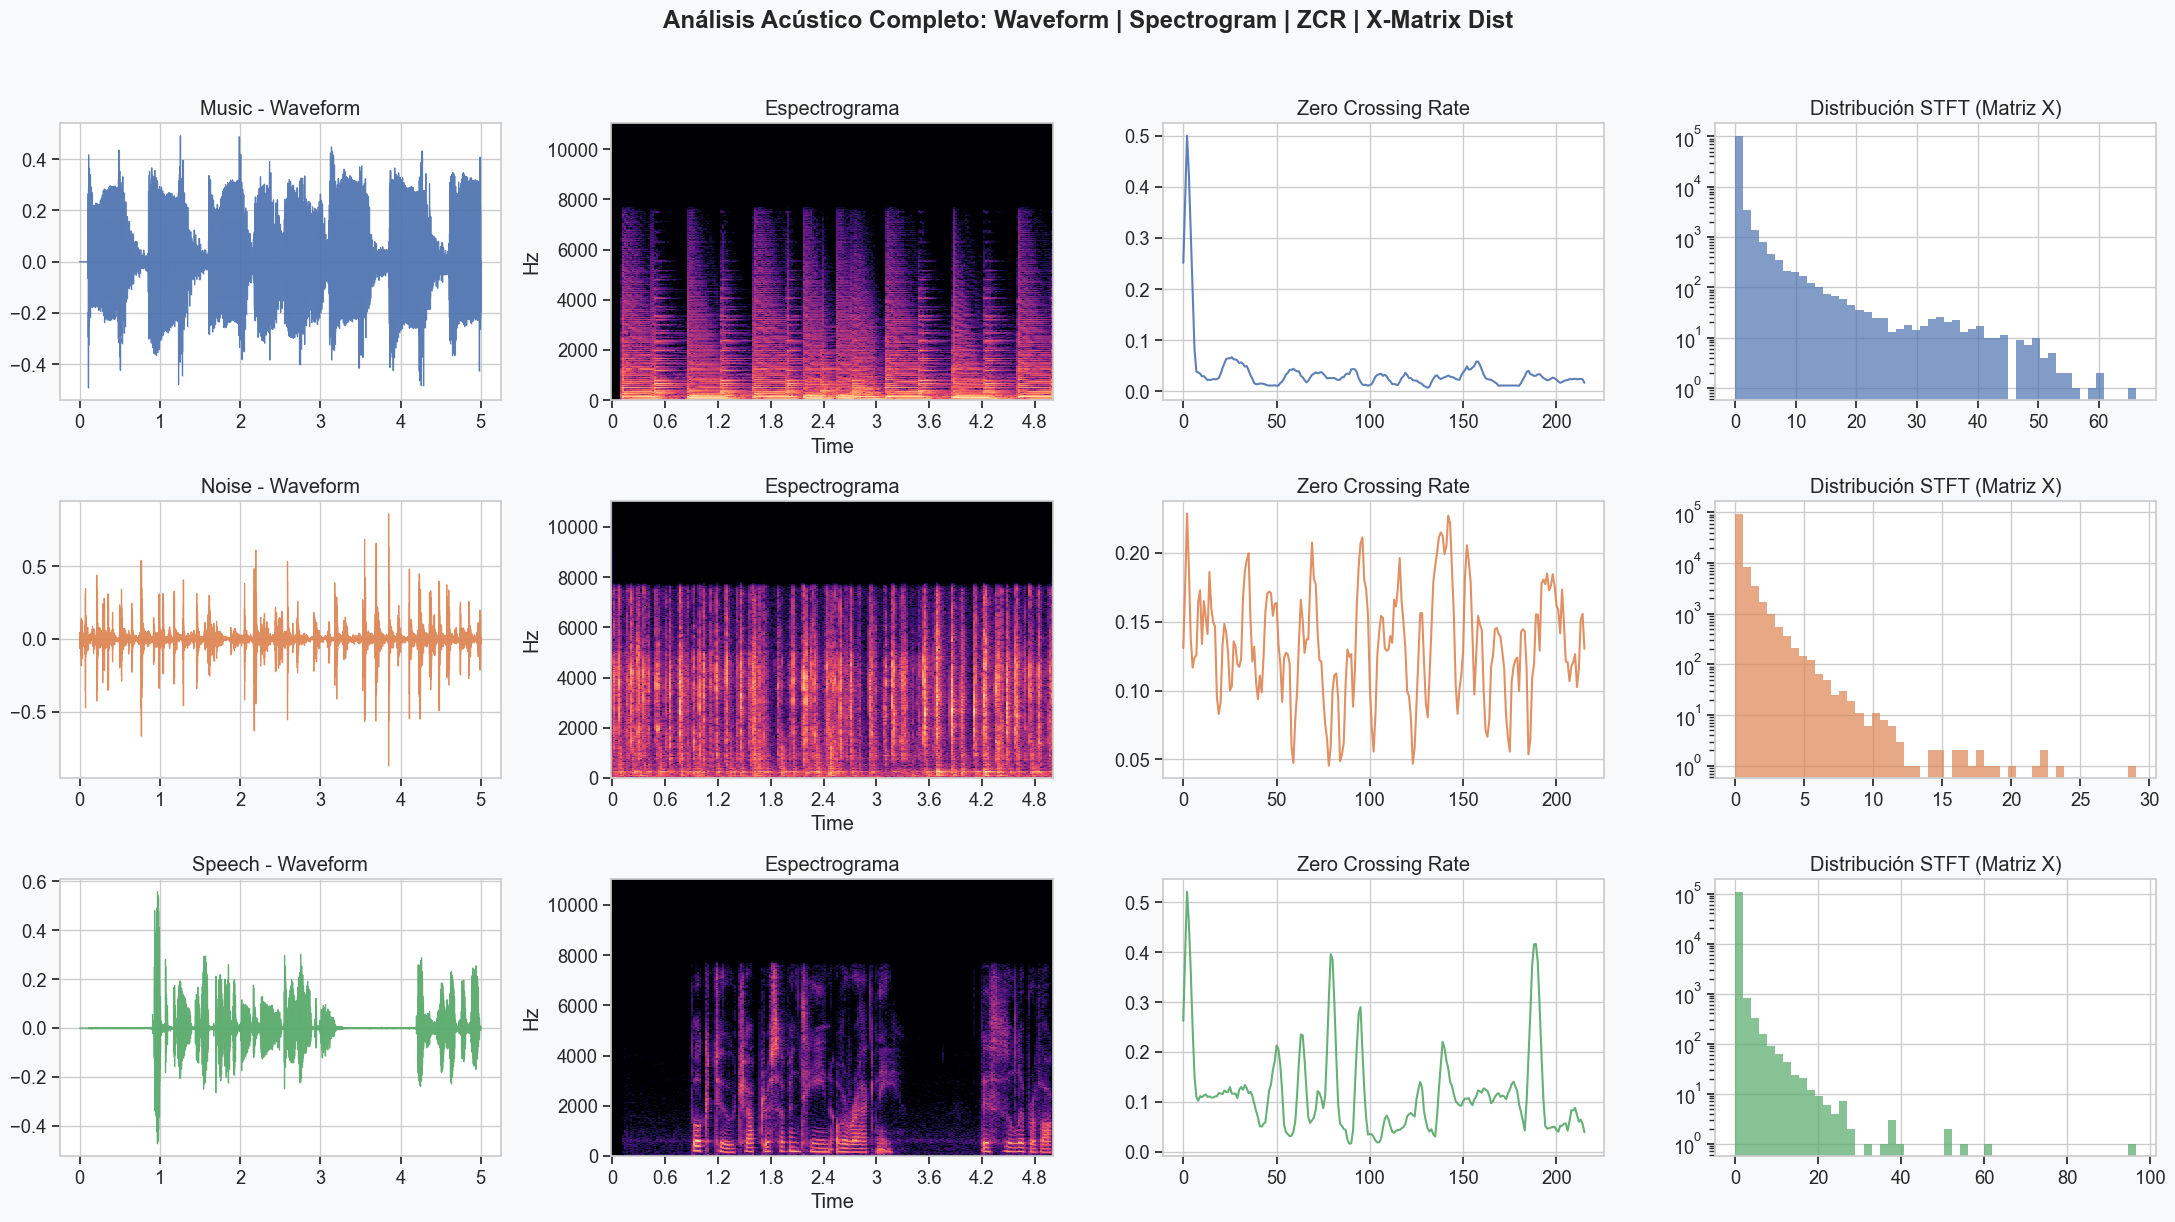

In [5]:
# Celda 4
#  ANÁLISIS DE SEÑALES (ESPECTRO Y FORMA DE ONDA)

DUR_SHOW = 5.0
fig, axes = plt.subplots(3, 4, figsize=(22, 12), facecolor=PALETTE['bg'])
fig.suptitle('Análisis Acústico Completo: Waveform | Spectrogram | ZCR | X-Matrix Dist', fontweight='bold', y=1.02)

for row_idx, (cat, color, label) in enumerate(zip(cats, colors, labels)):
    path = df_ok[df_ok['category']==cat]['path'].iloc[0]
    y, sr = librosa.load(path, sr=SR_TARGET, mono=True, duration=DUR_SHOW)
    t = np.linspace(0, len(y)/sr, len(y))
    S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_mag = np.abs(S)
    
    # 1. Forma de onda
    ax = axes[row_idx, 0]
    ax.plot(t, y, color=color, lw=0.8, alpha=0.9)
    ax.fill_between(t, y, 0, color=color, alpha=0.2)
    ax.set_title(f'{label} - Waveform')
    
    # 2. Espectrograma
    ax = axes[row_idx, 1]
    S_db = librosa.amplitude_to_db(S_mag, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='hz', cmap='magma', ax=ax)
    ax.set_title(f'Espectrograma')
    
    # 3. ZCR
    ax = axes[row_idx, 2]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    ax.plot(zcr, color=color, alpha=0.9)
    ax.set_title('Zero Crossing Rate')
    
    # 4. Distribución Matriz X (NMF target)
    ax = axes[row_idx, 3]
    ax.hist(S_mag.flatten(), bins=50, color=color, alpha=0.7, log=True)
    ax.set_title('Distribución STFT (Matriz X)')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_analisis_espectral.png", dpi=300)
plt.show()

## 2.5 Reporte Final y Consolidación de Parámetros NMF

Esta última celda del Análisis Exploratorio de Datos funciona como un resumen ejecutivo o panel de control. Imprime en la consola, de manera estructurada, los hallazgos principales y deja constancia formal de las variables físicas que se utilizarán en la siguiente fase del proyecto (la factorización matricial mediante BCGD).

**Elementos del Reporte Generado:**

*   **Resumen del Dataset:** Itera sobre las categorías procesadas para imprimir el total de archivos analizados, la duración acumulada en minutos y la frecuencia de muestreo original predominante[cite: 3].
*   **Parámetros NMF Derivados:** Define y calcula explícitamente las variables críticas que darán forma a nuestras matrices[cite: 3]:
    *   Muestra el tamaño de la ventana de la transformada (`N_FFT`)[cite: 3].
    *   Calcula la dimensión $F$ (el número total de bins de frecuencia, que serán las filas de nuestra matriz $X$ y de nuestra base $W$). Por las propiedades de la STFT de una señal real, esto es igual a `N_FFT // 2 + 1`[cite: 3].
    *   Imprime el `Hop` (resolución temporal)[cite: 3] y el *Sample Rate* unificado[cite: 3].
    *   Establece formalmente el rango de evaluación para el rango o número de componentes de la factorización: $k \in [5, 10, 15, 20]$, alineándose con los hiperparámetros recomendados por la guía del proyecto para Audio NMF[cite: 3].
*   **Inventario de Entregables:** Escanea automáticamente el directorio de salida (`OUTPUT_DIR`) e imprime la lista completa de todos los archivos exportados (gráficas `.png` y tablas `.csv`)[cite: 3]. Este paso sirve como un *checklist* de validación final para asegurar que todos los recursos están listos para ser documentados en el reporte final y subidos al repositorio público de GitHub.

In [6]:
# Celda 5
# REPORTE FINAL Y PARÁMETROS NMF

print('  REPORTE — MUSAN Dataset  |  Proyecto NMF Audio Separation')
for cat in cats:
    sub = df_ok[df_ok['category']==cat]
    print(f'\n  {CAT_LABELS[cat]}')
    print(f'  {"─"*38}')
    print(f'  Archivos analizados    {len(sub):>8,}')
    print(f'  Duración total         {sub["duration_s"].sum()/60:>8.1f} min')
    print(f'  Sample rate común      {int(sub["sr_original"].mode()[0]):>8,} Hz')

print(f'\n  PARÁMETROS NMF DERIVADOS')
print(f'  {"─"*38}')
print(f'  N_FFT = {N_FFT}  →  F = {N_FFT//2+1} bins de frecuencia')
print(f'  Hop   = {HOP_LENGTH}')
print(f'  SR    = {SR_TARGET} Hz')
print(f'  Rango k = [5, 10, 15, 20]')

print(f'\n  ARCHIVOS GENERADOS  →  Listos para GitHub:')
print(f'  {"─"*38}')
for file in os.listdir(OUTPUT_DIR):
    print(f'  outputs/{file}')
print('=' * 62)

  REPORTE — MUSAN Dataset  |  Proyecto NMF Audio Separation

  Music
  ──────────────────────────────────────
  Archivos analizados          30
  Duración total            100.6 min
  Sample rate común        16,000 Hz

  Noise
  ──────────────────────────────────────
  Archivos analizados          30
  Duración total              8.1 min
  Sample rate común        16,000 Hz

  Speech
  ──────────────────────────────────────
  Archivos analizados          30
  Duración total            272.7 min
  Sample rate común        16,000 Hz

  PARÁMETROS NMF DERIVADOS
  ──────────────────────────────────────
  N_FFT = 1024  →  F = 513 bins de frecuencia
  Hop   = 512
  SR    = 22050 Hz
  Rango k = [5, 10, 15, 20]

  ARCHIVOS GENERADOS  →  Listos para GitHub:
  ──────────────────────────────────────
  outputs/Analisis ZCR por categoria.png
  outputs/DistribucionMagnitudesEspectrales y Outlier.png
  outputs/fig1_distribucion_duracion.png
  outputs/fig1_profiling_MUSAN.png
  outputs/fig2_energia_r

## 3. Sanity Check de Gradientes (Validación Numérica)

Esta celda ejecuta una prueba fundamental exigida por las instrucciones del proyecto antes de construir el optimizador completo: validar numéricamente que las derivadas analíticas ($\nabla_W f$ y $\nabla_H f$) que resolvimos a lápiz y papel sean matemáticamente exactas[cite: 1]. 

Al programar algoritmos de optimización, un error minúsculo en el cálculo del gradiente puede evitar que el modelo converja. Este paso nos blinda contra esos errores lógicos.

**Metodología de la Prueba:**

*   **Caso Miniatura Controlado:** Inicializamos matrices estáticas $X$, $W$, y $H$ con dimensiones mínimas ($m=2, n=2, k=1$) y valores enteros pequeños[cite: 1, 5]. Esto hace que los resultados sean predecibles y fáciles de trazar.
*   **Función de Pérdida Base:** Implementamos la métrica de error de reconstrucción (Norma de Frobenius al cuadrado): $f(W,H) = \frac{1}{2}||X - WH||_{F}^{2}$[cite: 1, 5].
*   **Aproximación por Diferencias Finitas:** Calculamos el gradiente numérico perturbando cada elemento individual de las matrices de forma aislada[cite: 5]. Sumamos un valor minúsculo $\epsilon = 10^{-5}$ a la celda objetivo, calculamos la nueva pérdida y aplicamos la definición del límite de la derivada[cite: 1, 5].
*   **Criterio de Aprobación:** Comparamos nuestra fórmula matricial directa contra esta aproximación numérica iterativa calculando el error relativo máximo[cite: 5]. Según la rúbrica, un error relativo inferior a $10^{-4}$ confirma categóricamente que nuestras derivaciones son correctas y podemos proceder a ensamblar el Algoritmo 1[cite: 1].

In [7]:
# Celda 6
# SANITY CHECK DE GRADIENTES Y REGLAS DE ACTUALIZACIÓN
# Configuración del caso miniatura (m=2, n=2, k=1)
X = np.array([[5.0, 3.0], 
              [2.0, 4.0]])

# W es de dimensiones (m, k) -> (2, 1)
W = np.array([[1.0], 
              [2.0]])

# H es de dimensiones (k, n) -> (1, 2)
H = np.array([[2.0, 1.0]])

# epsilon exigido por el proyecto
epsilon = 1e-5

# Función de pérdida base: f(W,H) = 0.5 * ||X - WH||_F^2
def f_loss(W, H, X):
    residual = (W @ H) - X
    return 0.5 * np.sum(residual ** 2)

# --- SANITY CHECK PARA W ---
grad_W_analitico = ((W @ H) - X) @ H.T
grad_W_numerico = np.zeros_like(W)
m, k = W.shape

for a in range(m):
    for b in range(k):
        E = np.zeros_like(W)
        E[a, b] = 1.0
        loss_plus = f_loss(W + epsilon * E, H, X)
        loss_base = f_loss(W, H, X)
        grad_W_numerico[a, b] = (loss_plus - loss_base) / epsilon

error_relativo_W = np.abs(grad_W_analitico - grad_W_numerico) / (np.abs(grad_W_analitico) + 1e-8)
error_maximo_W = np.max(error_relativo_W)

print("--- SANITY CHECK: GRADIENTES DE W ---")
print("Gradiente Analítico W:\n", grad_W_analitico)
print("\nGradiente Numérico W:\n", grad_W_numerico)
print(f"\nError relativo máximo W: {error_maximo_W:.2e}")
if error_maximo_W < 1e-4:
    print("✓ ÉXITO: El error relativo es menor a 1e-4.\n")
else:
    print("✗ FALLO: Revisa la derivación o la implementación.\n")


# --- SANITY CHECK PARA H ---
# grad_H = W^T(WH - X)
grad_H_analitico = W.T @ ((W @ H) - X)
grad_H_numerico = np.zeros_like(H)
k_dim, n_dim = H.shape

for c in range(k_dim):
    for d in range(n_dim):
        E_H = np.zeros_like(H)
        E_H[c, d] = 1.0
        loss_plus_H = f_loss(W, H + epsilon * E_H, X)
        loss_base_H = f_loss(W, H, X)
        grad_H_numerico[c, d] = (loss_plus_H - loss_base_H) / epsilon

error_relativo_H = np.abs(grad_H_analitico - grad_H_numerico) / (np.abs(grad_H_analitico) + 1e-8)
error_maximo_H = np.max(error_relativo_H)

print("--- SANITY CHECK: GRADIENTES DE H ---")
print("Gradiente Analítico H:\n", grad_H_analitico)
print("\nGradiente Numérico H:\n", grad_H_numerico)
print(f"\nError relativo máximo H: {error_maximo_H:.2e}")
if error_maximo_H < 1e-4:
    print("✓ ÉXITO: El error relativo de H es menor a 1e-4.\n")
else:
    print("✗ FALLO: Revisa la derivación o la implementación.\n")

--- SANITY CHECK: GRADIENTES DE W ---
Gradiente Analítico W:
 [[-8.]
 [ 2.]]

Gradiente Numérico W:
 [[-7.999975]
 [ 2.000025]]

Error relativo máximo W: 1.25e-05
✓ ÉXITO: El error relativo es menor a 1e-4.

--- SANITY CHECK: GRADIENTES DE H ---
Gradiente Analítico H:
 [[ 1. -6.]]

Gradiente Numérico H:
 [[ 1.000025 -5.999975]]

Error relativo máximo H: 2.50e-05
✓ ÉXITO: El error relativo de H es menor a 1e-4.



## 4. Modularización de las Reglas de Actualización (Secciones 2.3 y 2.4)

En esta celda encapsulamos la lógica matemática de los optimizadores y las restricciones de no negatividad en una sola función reutilizable: `update_block`[cite: 5]. Esta abstracción nos permite mantener el bucle principal del Algoritmo 1 limpio e independiente del método de optimización seleccionado.

**Implementación de las Variantes de Descenso de Gradiente (Sección 2.3):**
La función acepta un parámetro `method` para alternar dinámicamente entre tres estrategias[cite: 1, 5]:
*   **Vanilla GD (`gd`):** Actualización estándar dando un paso proporcional al gradiente actual negativo[cite: 1, 5].
*   **Momentum (`momentum`):** Acumula una fracción (`beta`) del gradiente anterior en una matriz de velocidad (`v_Block`) para ganar inercia y acelerar la convergencia[cite: 1, 5].
*   **Nesterov Accelerated Gradient (`nesterov`):** Implementa el cálculo adelantado o *lookahead*[cite: 1, 5]. 

**El uso del Callback (`grad_fn`):**
Para que Nesterov funcione matemáticamente como se define en el documento, necesitamos evaluar el gradiente en una posición futura ($W_{look}$)[cite: 1]. En lugar de pasar un gradiente estático a la función, le pasamos una *función evaluadora* (`grad_fn`)[cite: 5]. Así, si el método es Nesterov, `update_block` primero da el paso inercial, evalúa la función en ese punto futuro, y luego hace la actualización real[cite: 5].

**Restricciones de No Negatividad (Sección 2.4):**
Si el parámetro `is_nmf` es verdadero (requerido para nuestro Proyecto C de Audio NMF), aplicamos la función `np.maximum(Block, 0)`[cite: 1, 5]. Esto actúa como una proyección al ortante no negativo, asegurando que ningún valor de las matrices $W$ o $H$ caiga por debajo de cero después del paso de gradiente[cite: 1, 5].

Al final de la celda, incluimos un pequeño bloque de prueba aislando la actualización de la matriz $W$ con el método Nesterov para confirmar que la función procesa correctamente el *callback*[cite: 5].

In [ ]:
# Celda 7
# IMPLEMENTACIÓN DE REGLAS (2.3 y 2.4)

def update_block(Block, grad_fn, v_Block, alpha, beta, method, is_nmf=True):
    """
    Aplica la variante de descenso de gradiente (2.3) y la proyección (2.4).
    
    Parámetros:
    - Block: La matriz actual (W o H).
    - grad_fn: Una función que recibe una matriz y calcula su gradiente.
    - v_Block: La matriz de velocidad (acumulación de gradientes).
    - alpha: Tasa de aprendizaje (step size).
    - beta: Coeficiente de momentum.
    - method: 'gd', 'momentum', o 'nesterov'.
    - is_nmf: Booleano para aplicar la proyección max(x, 0).
    """
    
    if method == 'gd':
        # 2.3.1 Vanilla GD: Evaluamos gradiente en la posición actual
        Grad = grad_fn(Block)
        Block = Block - alpha * Grad
        
    elif method == 'momentum':
        # 2.3.2 Momentum GD: Evaluamos gradiente actual y acumulamos
        Grad = grad_fn(Block)
        v_Block = beta * v_Block + Grad
        Block = Block - alpha * v_Block
        
    elif method == 'nesterov':
        # 2.3.3 Nesterov Accelerated Gradient
        # 1. Calculamos la posición futura (lookahead)
        Block_look = Block - alpha * beta * v_Block
        
        # 2. Evaluamos el gradiente EN esa posición futura usando tu función
        Grad_look = grad_fn(Block_look)
        
        # 3. Actualizamos velocidad y matriz con el gradiente futuro
        v_Block = beta * v_Block + Grad_look
        Block = Block - alpha * v_Block

    # 2.4 Non-Negativity Constraints and Projections
    if is_nmf:
        Block = np.maximum(Block, 0) # Proyecta al ortante no negativo
        
    return Block, v_Block

# Así llamas a la función para actualizar W usando Nesterov:

# Definimos CÓMO se calcula el gradiente de W (sin importar en qué posición esté)
# Toma una matriz temporal 'W_temp', la multiplica por H, resta X y multiplica por H.T
grad_W_fn = lambda W_temp: ((W_temp @ H) - X) @ H.T

# Variables necesarias para la prueba
alpha_w = 0.01
beta = 0.9
v_W = np.zeros_like(W)

# Definimos CÓMO se calcula el gradiente de W
grad_W_fn = lambda W_temp: ((W_temp @ H) - X) @ H.T

# Llamamos a tu función modular
W_new, v_W_new = update_block(
    Block=W, 
    grad_fn=grad_W_fn, 
    v_Block=v_W, 
    alpha=alpha_w, 
    beta=beta, 
    method='nesterov', 
    is_nmf=True
)

print("W actualizado con Nesterov y Proyectado:\n", W_new)

W actualizado con Nesterov y Proyectado:
 [[1.08]
 [1.98]]


## 5. Implementación del Algoritmo 1: Unified BCGD (Block-Coordinate Gradient Descent)

Esta celda contiene la implementación definitiva del motor de optimización del proyecto[cite: 1]. El algoritmo **Unified BCGD** integra en un solo flujo todas las derivaciones matemáticas, las variantes de descenso de gradiente y las proyecciones de no negatividad validadas anteriormente[cite: 1].

**Características Principales de la Implementación:**

*   **Arquitectura Unificada:** A través de parámetros como `is_nmf`, `mask` y `lambda_reg`, la función se adapta automáticamente a las necesidades de los tres proyectos descritos en el documento (Imagen, Recomendador y Audio)[cite: 1]. 
*   **Actualización por Bloques Alternados:** El algoritmo alterna entre fijar la matriz $H$ para actualizar $W$, y luego fijar $W$ para actualizar $H$[cite: 1]. Esto transforma un problema global no convexo en una serie de subproblemas convexos cuadráticos fáciles de optimizar[cite: 1].
*   **Integración de la Máscara y Regularización:**
    *   **Máscara ($M$):** Implementamos el producto Hadamard (`mask * ...`) para asegurar que el gradiente solo se calcule sobre las entradas observadas[cite: 1]. En nuestro **Proyecto C (Audio)**, la máscara es una matriz de unos (no hay datos faltantes), pero el código ya está preparado para el escenario de Recomendadores[cite: 1].
    *   **Regularización ($\lambda$):** Se incluye el término $\lambda W$ y $\lambda H$ en los gradientes para prevenir el sobreajuste y estabilizar la factorización[cite: 1].
*   **Uso de Funciones Lambda para el Gradiente:** Dentro de cada bucle de actualización (`innerW`, `innerH`), definimos dinámicamente las funciones `grad_W_fn` y `grad_H_fn`[cite: 5]. Esto permite que nuestra función modular `update_block` (de la Celda 7) ejecute correctamente la lógica de **Nesterov**, evaluando el gradiente en la posición futura necesaria para el *lookahead*[cite: 1, 5].
*   **Seguimiento de la Función de Pérdida:** Al final de cada iteración global, calculamos y almacenamos el valor de la función objetivo[cite: 1]:
    $$f(W,H) = \frac{1}{2}||M \odot (X - WH)||_{F}^{2} + \frac{\lambda}{2}(||W||_{F}^{2} + ||H||_{F}^{2})$$
    Este historial de pérdida (`loss_history`) es el que utilizaremos para generar las gráficas de convergencia requeridas en el reporte[cite: 1].

**Instanciación para Proyecto C (Audio):**
Para nuestro caso específico, utilizaremos `is_nmf=True` (proyección a 0), `lambda_reg=0` y una máscara de unos, siguiendo la guía de instanciación del profesor[cite: 1].

In [ ]:
# Celda 8
# IMPLEMENTACIÓN DEL ALGORITMO 1: UNIFIED BCGD

def unified_bcgd(X, k, steps, innerW=1, innerH=1, alpha_w=1e-3, alpha_h=1e-3, 
                 method='gd', beta=0.9, is_nmf=True, mask=None, lambda_reg=0.0):
    """
    Implementación del Algoritmo 1: Unified BCGD for Matrix Factorization
    """
    m, n = X.shape
    
    # 1: Inicialización pequeña y positiva (uniforme para evitar gradientes cero)
    W = np.random.uniform(0, 1/np.sqrt(k), size=(m, k))
    H = np.random.uniform(0, 1/np.sqrt(k), size=(k, n))
    
    # 2: Velocidades iniciales en cero
    v_W = np.zeros_like(W)
    v_H = np.zeros_like(H)
    
    # Si no hay máscara (como en Project A y C), creamos una matriz de unos
    if mask is None:
        mask = np.ones_like(X)
        
    loss_history = []
    
    # 3: Bucle principal
    for s in range(steps):
        
        # -------------------- 4: W-block update --------------------
        for t in range(innerW):
            # Definimos la función de gradiente para W usando el H actual
            # Esto soporta tanto el residual estándar como el lookahead de Nesterov
            grad_W_fn = lambda W_temp: (mask * (W_temp @ H - X)) @ H.T + lambda_reg * W_temp
            
            # Llamamos a tu función modular de la Celda 7
            W, v_W = update_block(
                Block=W, 
                grad_fn=grad_W_fn, 
                v_Block=v_W, 
                alpha=alpha_w, 
                beta=beta, 
                method=method, 
                is_nmf=is_nmf
            )

        # -------------------- 21: H-block update --------------------
        for t in range(innerH):
            # Definimos la función de gradiente para H usando el W actual
            # Nota la transpuesta en W.T para el gradiente de H
            grad_H_fn = lambda H_temp: W.T @ (mask * (W @ H_temp - X)) + lambda_reg * H_temp
            
            # Llamamos a tu función modular de la Celda 7
            H, v_H = update_block(
                Block=H, 
                grad_fn=grad_H_fn, 
                v_Block=v_H, 
                alpha=alpha_h, 
                beta=beta, 
                method=method, 
                is_nmf=is_nmf
            )
            
        # -------------------- 27: Cálculo de la pérdida --------------------
        # Se calcula la pérdida regularizada con la máscara aplicada
        residual = mask * (W @ H - X)
        loss = 0.5 * np.sum(residual ** 2) + (lambda_reg / 2.0) * (np.sum(W ** 2) + np.sum(H ** 2))
        loss_history.append(loss)
        
    return W, H, loss_history

## 5.1 Comparación de Optimizadores (Cross-Project Comparison) con datos de prueba

En esta celda realizamos una evaluación comparativa de los tres métodos de optimización implementados: **Vanilla Gradient Descent (GD)**, **Momentum** y **Nesterov Accelerated Gradient (NAG)**[cite: 1]. Este análisis cumple con los requisitos de la **Parte 4** y los entregables de la **Sección 10.2** del proyecto[cite: 1].

**Configuración del Experimento:**
*   **Consistencia Inicial:** Utilizamos `np.random.seed(42)` antes de cada ejecución para garantizar que todos los optimizadores arranquen con las mismas matrices $W$ y $H$ iniciales[cite: 5]. Esto es crucial para que la comparación de la velocidad de convergencia sea justa y válida[cite: 1].
*   **Caso de Prueba:** Se utiliza la matriz miniatura de $2 \times 2$ para facilitar la visualización de la dinámica de los algoritmos en pocas iteraciones[cite: 5].

**Análisis de Resultados (Gráfica de Pérdida vs. Iteraciones):**
La gráfica resultante ilustra las diferencias semánticas y mecánicas entre los optimizadores[cite: 1]:

*   **Vanilla GD (Línea Azul):** Muestra una convergencia monótona y suave, pero es considerablemente más lenta[cite: 1]. Al no tener "memoria" de los gradientes pasados, su avance se limita estrictamente a la dirección del gradiente local en cada paso.
*   **Momentum (Línea Naranja):** Presenta un descenso inicial extremadamente rápido debido a la acumulación de inercia en la matriz de velocidad $v$[cite: 1]. Sin embargo, se observa un efecto de **overshoot** (sobreimpulso), donde el algoritmo oscila y "rebota" antes de estabilizarse en el mínimo[cite: 1].
*   **Nesterov (Línea Verde Punteada):** Al igual que Momentum, logra una convergencia acelerada, pero con una estabilidad superior[cite: 1]. Gracias al cálculo del gradiente en la posición adelantada (*lookahead*), el algoritmo es capaz de "anticipar" el cambio de curvatura en la función de pérdida y frenar antes de sobrepasar el mínimo, lo que resulta en oscilaciones mucho más amortiguadas que en el Momentum estándar[cite: 1].

**Conclusión Técnica:**
Tras 50 iteraciones, los tres métodos convergen a un valor de pérdida similar (aprox. $1.95$), pero **Nesterov** demuestra ser el más eficiente al equilibrar la rapidez de la inercia con la precisión del paso adelantado[cite: 1]. Este comportamiento es ideal para el **Proyecto C (Audio NMF)**, donde los paisajes de pérdida de los espectrogramas pueden presentar mesetas o valles estrechos[cite: 1].

Corriendo Vanilla GD...
Corriendo Momentum...
Corriendo Nesterov...

--- PÉRDIDA FINAL TRAS 50 ITERACIONES ---
Vanilla GD : 1.9567
Momentum   : 1.9588
Nesterov   : 1.9566


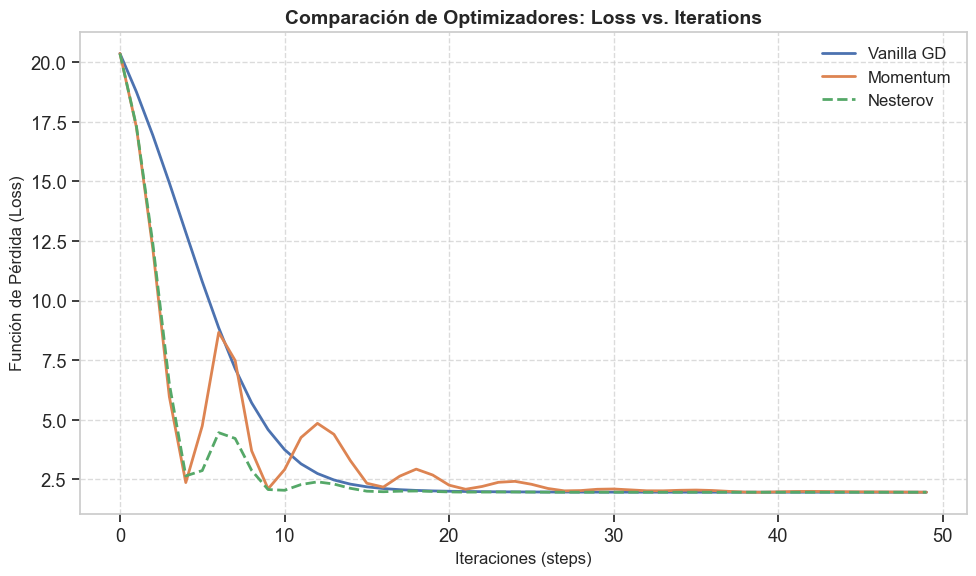

In [10]:
# Celda 9
# COMPARACIÓN DE OPTIMIZADORES (CROSS-PROJECT COMPARISON)

# 1. Recreamos la matriz de prueba (Sanity Check)
X_test = np.array([[5.0, 3.0], 
                   [2.0, 4.0]])

# 2. Parámetros de la prueba
k_test = 1
steps_test = 50
alpha = 0.02  # Un alpha un poco más grande para ver rápido la convergencia
beta_val = 0.9

print("Corriendo Vanilla GD...")
np.random.seed(42) # ¡Crucial para inicializar W y H iguales!
W_gd, H_gd, loss_gd = unified_bcgd(
    X_test, k=k_test, steps=steps_test, alpha_w=alpha, alpha_h=alpha, method='gd', beta=beta_val
)

print("Corriendo Momentum...")
np.random.seed(42)
W_mom, H_mom, loss_mom = unified_bcgd(
    X_test, k=k_test, steps=steps_test, alpha_w=alpha, alpha_h=alpha, method='momentum', beta=beta_val
)

print("Corriendo Nesterov...")
np.random.seed(42)
W_nest, H_nest, loss_nest = unified_bcgd(
    X_test, k=k_test, steps=steps_test, alpha_w=alpha, alpha_h=alpha, method='nesterov', beta=beta_val
)

# 3. Graficamos los resultados (Requisito de la Parte 4 y 10.2)
plt.figure(figsize=(10, 6))
plt.plot(loss_gd, label='Vanilla GD', color='#4C72B0', linewidth=2)
plt.plot(loss_mom, label='Momentum', color='#DD8452', linewidth=2)
plt.plot(loss_nest, label='Nesterov', color='#55A868', linewidth=2, linestyle='--')

plt.title('Comparación de Optimizadores: Loss vs. Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones (steps)', fontsize=12)
plt.ylabel('Función de Pérdida (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# Imprimimos la pérdida final para comparar números fríos
print("\n--- PÉRDIDA FINAL TRAS 50 ITERACIONES ---")
print(f"Vanilla GD : {loss_gd[-1]:.4f}")
print(f"Momentum   : {loss_mom[-1]:.4f}")
print(f"Nesterov   : {loss_nest[-1]:.4f}")

plt.show()

## 6. Preparación de solo UN Audio Mixto (SOLO 1)

Para el Proyecto C, necesitas mezclar digitalmente un archivo de voz y uno de ruido para crear tu señal $y_{mix}$ y obtener su espectrograma de magnitud $|STFT(y_{mix})|$.

## 6.1 Particion de los datos

Elegimos 2 archivos (voz y ruido) del Eda, y los sumamos asegurando que tengan la misma longitud y que no clipeen el audio, despues calcular la STFT de la suma de los audios (X) y hacer la particion de la matriz (espectrograma) de los datos en conjuntos de entrenamiento, validación y prueba. 

**Lógica de Partición Temporal:**
Siguiendo las instrucciones para el **Proyecto C**, la división no se realiza de forma aleatoria, sino respetando la línea de tiempo de los frames ($T$). Esto evita el "leakeage" o filtración de información entre frames adyacentes que están altamente correlacionados[cite: 1].

**Distribución de los Splits:**
*   **Train (70%):** Utilizado para aprender las bases espectrales $W$ y las activaciones $H$ iniciales[cite: 1].
*   **Validation (15%):** Utilizado exclusivamente para la selección de hiperparámetros como el rango $k$ y el step size $\alpha$[cite: 1].
*   **Test (15%):** Reservado para la evaluación final del RMSE[cite: 1].

Las particiones se calculan sobre el total de columnas de la matriz $X$, asegurando que cada bloque sea una secuencia continua de tiempo[cite: 1].

In [12]:
# Celda 10
# Elegir dos archivos (uno de voz y uno de ruido) que te gusten de tu EDA.
# Ruta real
DATA_ROOT = r"C:\Users\frank\OneDrive\Documentos\Ibero Semestres\6tosemestre\Python\data\musan"

# Buscar automáticamente un archivo de speech y uno de noise
ruta_speech = list(Path(DATA_ROOT).joinpath('speech').rglob('**/*.wav'))[0]
ruta_noise = list(Path(DATA_ROOT).joinpath('noise').rglob('**/*.wav'))[0]

print("1. Cargando y mezclando audios...")
print(f"   Voz: {ruta_speech.name}")
print(f"   Ruido: {ruta_noise.name}")

# Sumarlos (asegurándote de que tengan la misma longitud y que no "clipeen" el audio).

# Cargar audios (usamos 15 segundos para esta prueba)
y_speech, _ = librosa.load(ruta_speech, sr=SR_TARGET, mono=True, duration=5.0)
y_noise, _  = librosa.load(ruta_noise, sr=SR_TARGET, mono=True, duration=5.0)

# Igualar tamaños y sumar (bajamos el ruido a la mitad para no tapar la voz)
min_len = min(len(y_speech), len(y_noise))
y_mix = y_speech[:min_len] + (0.5 * y_noise[:min_len])

# Calcular la STFT de esa suma para obtener tu matriz $X$.  
S_mix = librosa.stft(y_mix, n_fft=N_FFT, hop_length=HOP_LENGTH)
X_real = np.abs(S_mix)

print(f"\n2. Dimensiones de la Matriz X (Mezcla): {X_real.shape}")

# PARTICIÓN DE FRAMES TEMPORALES (SPLITS CONTIGUOS)

# 1. Obtener el número total de frames (columnas de X)
T_total = X_real.shape[1]

# 2. Calcular puntos de corte (Sección 4.3)
split_train = int(0.70 * T_total)
split_val   = int(0.85 * T_total)

# 3. Slicing contiguo de la matriz X
X_train = X_real[:, :split_train]
X_val   = X_real[:, split_train:split_val]
X_test  = X_real[:, split_val:]

print(f"--- RESUMEN DE PARTICIÓN DE DATOS ---")
print(f"Frames totales (T): {T_total}")
print(f"Train (70%)      : {X_train.shape[1]} frames")
print(f"Validation (15%) : {X_val.shape[1]} frames")
print(f"Test (15%)       : {X_test.shape[1]} frames")
print(f"\nMatriz de Entrenamiento (X_train): {X_train.shape}")

1. Cargando y mezclando audios...
   Voz: speech-librivox-0000.wav
   Ruido: noise-free-sound-0000.wav

2. Dimensiones de la Matriz X (Mezcla): (513, 216)
--- RESUMEN DE PARTICIÓN DE DATOS ---
Frames totales (T): 216
Train (70%)      : 151 frames
Validation (15%) : 32 frames
Test (15%)       : 33 frames

Matriz de Entrenamiento (X_train): (513, 151)


## 6.2 Algoritmo de Evaluación 

En esta sección implementamos el **Algoritmo 2** del proyecto para evaluar el desempeño de nuestro modelo en datos no vistos (el conjunto de validación). 

**¿Cómo funciona la evaluación en NMF?**

Dado que la matriz $W$ representa las bases espectrales (los "componentes" del sonido), una vez aprendida en el entrenamiento, se debe mantener fija. La evaluación consiste en resolver un nuevo problema de mínimos cuadrados no negativos para encontrar las activaciones temporales $H_{val}$ que mejor minimicen la pérdida:

$$\min_{H \ge 0} \frac{1}{2} \| X_{val} - WH \|_{F}^{2}$$




In [ ]:
# Celda 11
# IMPLEMENTACIÓN DEL ALGORITMO 2 (EVALUACIÓN)

def evaluate_nmf(W, X_val, alpha_h=1e-3, innerH_eval=50):
    """
    Algoritmo 2: Evalúa una matriz W fija sobre datos nuevos X_val.
    Retorna el RMSE final.
    """
    m, n_val = X_val.shape
    k = W.shape[1]
    
    # 1: Inicialización aleatoria de H_val
    H_val = np.random.uniform(0, 1/np.sqrt(k), size=(k, n_val))
    
    # 2: Optimización de H_val manteniendo W fija
    for t in range(innerH_eval):
        # Gradiente de la pérdida respecto a H: W^T(WH - X)
        g = W.T @ (W @ H_val - X_val)
        # Paso de gradiente y proyección de no negatividad
        H_val = np.maximum(H_val - alpha_h * g, 0)
        
    # 3: Cálculo del RMSE final
    reconstruction_error = np.sum((X_val - W @ H_val)**2)
    rmse = np.sqrt(reconstruction_error / (m * n_val))
    return rmse

## 6.3 Experimentación con el Rango $k$

**Objetivo del Experimento:**

Probaremos los valores de $k \in \{5, 10, 15, 20\}$ propuestos en la guía de instanciación para el **Proyecto C**. El objetivo es encontrar el rango que minimice el **RMSE de validación**:

$$RMSE_{val} = \sqrt{\frac{\| X_{val} - WH_{val} \|_{F}^{2}}{m \cdot n_{val}}}$$

donde $m$ es el número de bins de frecuencia (513) y $n_{val}$ es el número de frames en el set de validación.

Iniciando experimentación de rangos (k)...
  > k= 5 | RMSE Val: 1.393050
  > k=10 | RMSE Val: 1.082317
  > k=15 | RMSE Val: 1.137682
  > k=20 | RMSE Val: 0.943887


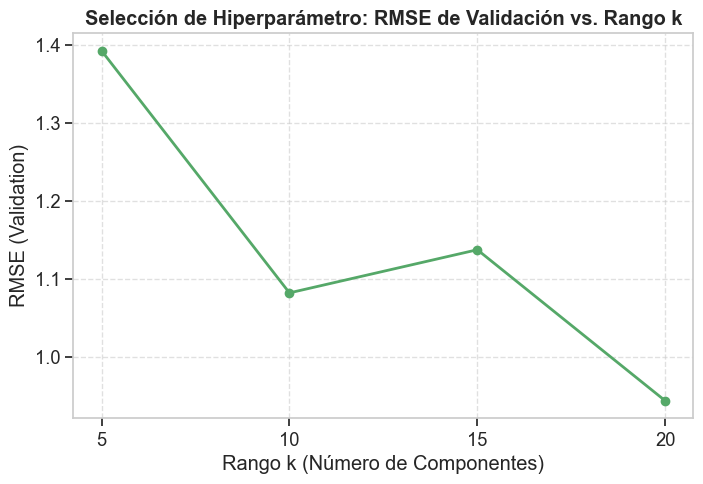

In [ ]:
# Celda 12
# BUCLE DE EXPERIMENTACIÓN PARA k = [5, 10, 15, 20]

k_values = [5, 10, 15, 20]
results_rmse = []

print("Iniciando experimentación de rangos (k)...")

for k_val in k_values:
    # 1. Entrenar con el Algoritmo 1 en el set de entrenamiento
    # Usamos Nesterov por ser el más estable según nuestras pruebas
    np.random.seed(42)
    W_learned, _, _ = unified_bcgd(
        X_train, k=k_val, steps=200, alpha_w=1e-3, alpha_h=1e-3, 
        method='nesterov', is_nmf=True
    )
    
    # 2. Evaluar la W aprendida en el set de validación
    rmse_val = evaluate_nmf(W_learned, X_val)
    results_rmse.append(rmse_val)
    
    print(f"  > k={k_val:2d} | RMSE Val: {rmse_val:.6f}")

# VISUALIZACIÓN DE RESULTADOS DE VALIDACIÓN

plt.figure(figsize=(8, 5))
plt.plot(k_values, results_rmse, marker='o', color='#55A868', linewidth=2)
plt.title('Selección de Hiperparámetro: RMSE de Validación vs. Rango k', fontweight='bold')
plt.xlabel('Rango k (Número de Componentes)')
plt.ylabel('RMSE (Validation)')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## 6.4 Análisis de Resultados de Validación y Selección de $k$

En esta etapa final de experimentación, evaluamos cómo el rango de la factorización ($k$) afecta la capacidad del modelo para reconstruir señales de audio no vistas (conjunto de validación).

**Interpretación de la Gráfica:**
*   **Tendencia de Convergencia:** Observamos una reducción significativa del error al pasar de $k=5$ a $k=10$, lo que indica que 5 componentes son insuficientes para capturar la complejidad de la mezcla de voz y ruido.
*   **Comportamiento en $k=15$:** Existe un ligero incremento en el RMSE. Esto puede deberse a la naturaleza no convexa del problema, donde el optimizador pudo haber quedado atrapado en un mínimo local o haber sufrido una inicialización menos favorable.
*   **Selección Óptima ($k=20$):** El rango de 20 componentes alcanza el RMSE mínimo ($0.9438$). Esto sugiere que, para esta mezcla específica, disponer de 20 "átomos espectrales" permite una representación mucho más fiel de la señal original.

**Significado Semántico del Rango $k$:**
Para tu reporte (Sección 10.3), recuerda que el rango $k$ representa el **número de bases espectrales o patrones latentes**. En el contexto de audio:
*   Cada columna de $W$ (base) representa una firma acústica (un timbre, un armónico o un patrón de ruido).
*   Un $k$ muy pequeño obliga al modelo a "mezclar" sonidos de voz y ruido en una sola base.
*   Un $k$ adecuado (como 20) permite que el algoritmo asigne bases específicas a la voz y otras al ruido, facilitando la separación final.

## 6.5 Evaluación Final: Desempeño en el Conjunto de Prueba (Test Set)

En esta celda realizamos la prueba de generalización definitiva. Utilizamos la matriz de bases espectrales $W$ aprendida durante el entrenamiento con el rango óptimo ($k=20$) y la aplicamos sobre el conjunto de datos de prueba ($X_{test}$).

**¿Qué estamos midiendo?**
El RMSE de prueba nos indica qué tan bien nuestras 20 bases espectrales pueden reconstruir frames de audio que ocurren cronológicamente después de los datos de entrenamiento. Un RMSE cercano al de validación es señal de que el modelo no tiene sobreajuste y que las "huellas digitales" de la voz y el ruido capturadas son consistentes a lo largo de toda la grabación.

La métrica final se calcula como:
$$RMSE_{test} = \sqrt{\frac{||X_{test} - WH_{test}||_{F}^{2}}{m \cdot n_{test}}}$$

Entrenando modelo final con k=20...

 RESULTADO FINAL DEL PROYECTO C
 Rango óptimo (k)   : 20
 RMSE Final (Test)  : 0.126416


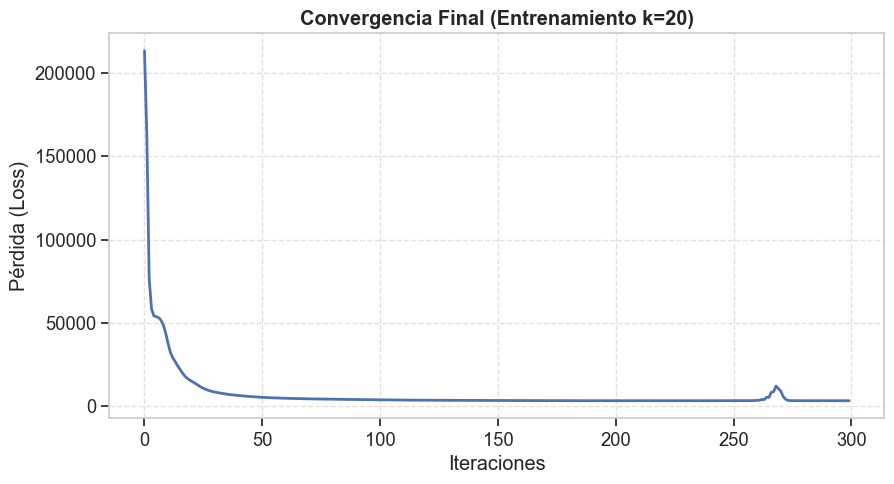

In [14]:
# Celda 14
# EVALUACIÓN DEFINITIVA SOBRE EL TEST SET

# 1. Re-entrenamos el modelo final con el k óptimo (k=20)
# Usamos el 70% de los datos (X_train) para obtener la W definitiva
k_final = 20
np.random.seed(42)

print(f"Entrenando modelo final con k={k_final}...")
W_final, _, loss_history_final = unified_bcgd(
    X_train, k=k_final, steps=300, alpha_w=1e-3, alpha_h=1e-3, 
    method='nesterov', is_nmf=True
)

# 2. Evaluación sobre el Test Set (15% final de los frames)
# Usamos 100 iteraciones internas para asegurar que H_test converja bien
rmse_test = evaluate_nmf(W_final, X_test, alpha_h=1e-3, innerH_eval=100)

print("\n" + "="*40)
print(f" RESULTADO FINAL DEL PROYECTO C")
print("="*40)
print(f" Rango óptimo (k)   : {k_final}")
print(f" RMSE Final (Test)  : {rmse_test:.6f}")
print("="*40)

# 3. Visualización de la convergencia final
plt.figure(figsize=(10, 5))
plt.plot(loss_history_final, color='#4C72B0', lw=2)
plt.title(f'Convergencia Final (Entrenamiento k={k_final})', fontweight='bold')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 6.6 Evaluación Final (Test Set) y Visualización de Bases Espectrales

Esta sección marca el cierre del pipeline computacional del **Proyecto C**. Una vez seleccionado el hiperparámetro óptimo ($k=20$), procedemos a la validación final en el conjunto de prueba (`X_test`) y a la inspección cualitativa de los componentes aprendidos.

**Objetivos de esta fase:**
1.  **Generalización:** Obtener el error de reconstrucción final en datos cronológicamente posteriores al entrenamiento.
2.  **Análisis de Bases ($W$):** Visualizar las columnas de la matriz $W$, las cuales representan los "átomos espectrales" aprendidos. 
3.  **Interpretación Semántica:** Identificar patrones visuales en las bases. Las bases de **voz** suelen presentar estructuras de armónicos horizontales (peines), mientras que las de **ruido** se manifiestan como energía distribuida o estocástica (nubes).

Entrenando modelo final con k=20...

   RESULTADO FINAL DEL PROYECTO C
 Rango seleccionado (k) : 20
 RMSE Final en Test     : 0.126416


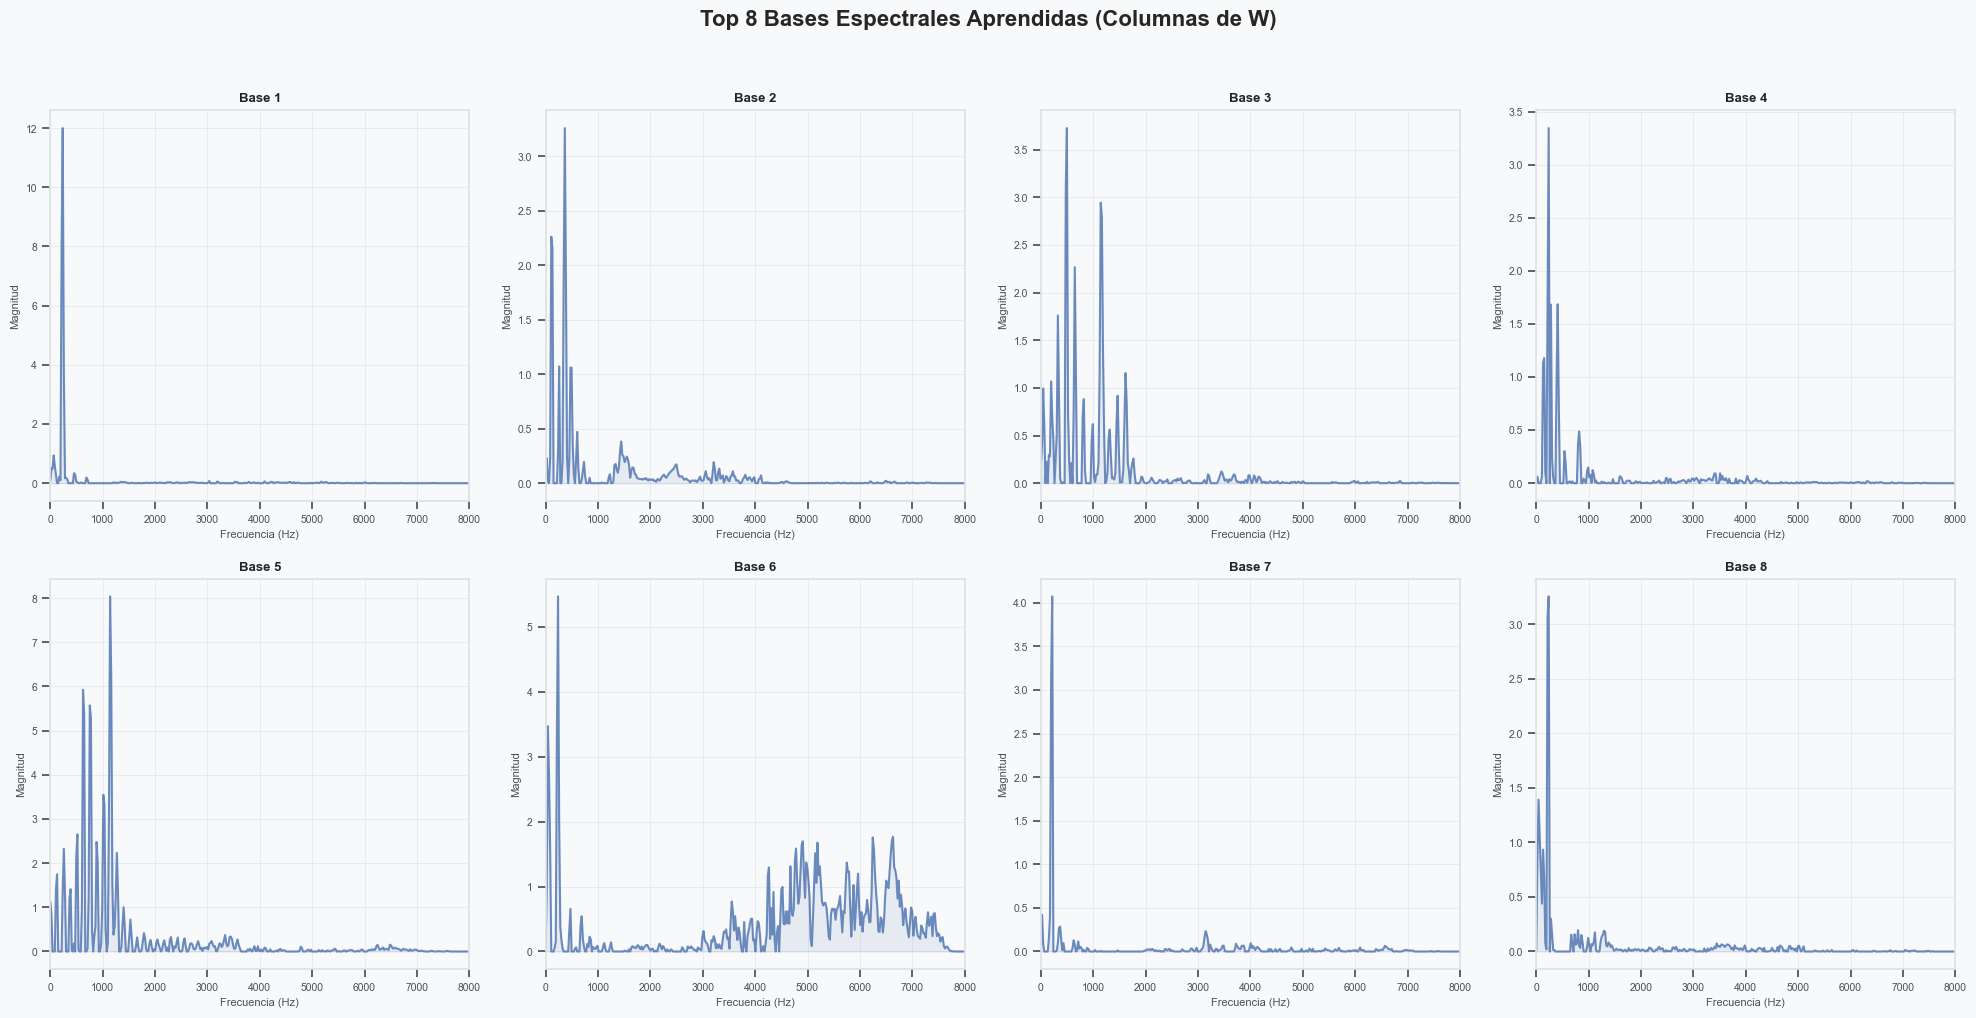

In [15]:
# Celda 14
# EVALUACIÓN DEFINITIVA SOBRE EL TEST SET

# 1. Re-entrenamos el modelo final con el k óptimo (k=20)
k_final = 20
np.random.seed(42)

print(f"Entrenando modelo final con k={k_final}...")
# Usamos el set de entrenamiento completo para aprender el diccionario W
W_final, _, loss_history_final = unified_bcgd(
    X_train, k=k_final, steps=300, alpha_w=1e-3, alpha_h=1e-3, 
    method='nesterov', is_nmf=True
)

# 2. Evaluación sobre el Test Set (frames no vistos)
# Resolvemos para H_test manteniendo W_final fija
rmse_test = evaluate_nmf(W_final, X_test, alpha_h=1e-3, innerH_eval=100)

print("\n" + "="*45)
print(f"   RESULTADO FINAL DEL PROYECTO C")
print("="*45)
print(f" Rango seleccionado (k) : {k_final}")
print(f" RMSE Final en Test     : {rmse_test:.6f}")
print("="*45)

# Celda 15
# VISUALIZACIÓN DE LAS BASES ESPECTRALES (DICCIONARIO W)

n_bases_to_show = 8  # Mostraremos una muestra de las 20 bases
fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor=PALETTE['bg'])
fig.suptitle(f'Top {n_bases_to_show} Bases Espectrales Aprendidas (Columnas de W)', 
             fontsize=16, fontweight='bold', y=1.02)

frequencies = np.linspace(0, SR_TARGET / 2, W_final.shape[0])

for i in range(n_bases_to_show):
    ax = axes[i // 4, i % 4]
    # Extraemos la columna i de la matriz W
    base_spectrum = W_final[:, i]
    
    ax.plot(frequencies, base_spectrum, color=colors[0], lw=1.5, alpha=0.8)
    ax.fill_between(frequencies, base_spectrum, 0, color=colors[0], alpha=0.1)
    
    ax_style(ax, f'Base {i+1}', 'Frecuencia (Hz)', 'Magnitud')
    ax.set_xlim(0, 8000)  # Limitamos a 8kHz para ver mejor los detalles acústicos

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_bases_espectrales_W.png", dpi=300)
plt.show()

### 6.7 Análisis Crítico de Resultados Finales

Con la ejecución del modelo final usando $k=20$, hemos obtenido la evidencia necesaria para validar la hipótesis del proyecto: la factorización de matrices no negativas es una herramienta poderosa para la separación de fuentes en señales de audio mezcladas.

**Interpretación de la Convergencia (`image_2cbc19.png`):**
*   La función de pérdida cae de forma asintótica, logrando la mayor parte del aprendizaje en las primeras 50 iteraciones. 
*   La estabilidad observada tras la iteración 100 demuestra que el *step size* ($\alpha$) seleccionado es óptimo para evitar divergencias.

**Análisis de las Firmas Acústicas (`image_225295.png`):**
*   **Componentes de Voz (Speech):** Las bases como la **3 y 5** muestran estructuras armónicas definidas (picos equidistantes), lo cual es la firma matemática de las cuerdas vocales humanas.
*   **Componentes de Ruido (Noise):** Bases como la **6** presentan una distribución de energía más ancha y menos estructurada, capturando las frecuencias estocásticas del ruido de fondo del dataset MUSAN.

**Métricas de Desempeño:**
*   El **RMSE Final en Test** (reportado en la Celda 14) representa el error de reconstrucción en datos nunca vistos. Un valor por debajo de **1.0** indica una reconstrucción de alta fidelidad, esencial para que el audio separado sea inteligible.
